In [1]:
import pandas as pd #판다스 패키지 불러오기
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sys

pd.set_option("display.max_columns", 100) #모든 열을 보여줌
plt.rc('font', family='Malgun Gothic')

ImportError: C extension: None not built. If you want to import pandas from the source directory, you may need to run 'python setup.py build_ext' to build the C extensions first.

# 데이터 불러오기

In [35]:
data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'

train_loan_df = pd.read_csv(data_path+'loan_df_train.csv')
test_loan_df = pd.read_csv(data_path+'loan_df_test.csv')
#log_df = pd.read_csv(data_path+'/log_data.csv')

# 파생변수 생성

## (대출희망금액 - 승인한도) Rank

In [37]:
# 동일 신청서내 (대출희망금액 - 승인한도) 계산
def make_loan_diff(train_loan_df):
    train_loan_df["amount_difference"] = train_loan_df["대출희망금액"] - train_loan_df["승인한도"]

    # user_id별로 그룹화 후 순위 매기기
    train_loan_df["한도_편차순위"] = train_loan_df.groupby(["유저_id","신청서_id"])["amount_difference"].rank(method="min", ascending=True)
    
    # 편차변수는 다시 식제
    train_loan_df = train_loan_df.drop('amount_difference',axis=1)
    return train_loan_df

train_loan_df = make_loan_diff(train_loan_df)
test_loan_df = make_loan_diff(test_loan_df)

## 승인금리 Rank  
- f1_score 5% 상승

In [ ]:
# 동일 신청서내 승인금액 순위 계산
train_loan_df["승인금리순위"] = train_loan_df.groupby(["유저_id","신청서_id"])["승인금리"].rank(method="min", ascending=True)
test_loan_df["승인금리순위"] = test_loan_df.groupby(["유저_id","신청서_id"])["승인금리"].rank(method="min", ascending=True)

print(train_loan_df.head())

In [40]:
print(test_loan_df.head())

    신청서_id               한도조회일시  금융사_id  상품_id        승인한도  승인금리  신청여부  \
0  1748340  2022-06-07 13:05:41       7    191  42000000.0  13.6   NaN   
1  1748340  2022-06-07 13:05:41      25    169  24000000.0  17.9   NaN   
2  1748340  2022-06-07 13:05:41       2      7  24000000.0  18.5   NaN   
3  1748340  2022-06-07 13:05:41       4    268  29000000.0  10.8   NaN   
4  1748340  2022-06-07 13:05:41      11    118   5000000.0  16.4   NaN   

      유저_id   성별         연소득  근로형태  고용형태  주거소유형태      대출희망금액  대출목적  신용등급  \
0  430982.0  1.0  24000000.0   0.0   0.0     2.0  25000000.0   1.0   7.0   
1  430982.0  1.0  24000000.0   0.0   0.0     2.0  25000000.0   1.0   7.0   
2  430982.0  1.0  24000000.0   0.0   0.0     2.0  25000000.0   1.0   7.0   
3  430982.0  1.0  24000000.0   0.0   0.0     2.0  25000000.0   1.0   7.0   
4  430982.0  1.0  24000000.0   0.0   0.0     2.0  25000000.0   1.0   7.0   

     나이  개인회생  기대출수유무  한도_편차순위  승인금리순위  
0  26.0   0.0     1.0      3.0    13.0  
1  26.0   0.0   

In [74]:
data_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/데이터셋/'

train_loan_df.to_csv(data_path+'loan_df_train(final).csv',index=False)
test_loan_df.to_csv(data_path+'loan_df_test(final).csv',index=False)

# 모델링

In [62]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score,classification_report,recall_score
from sklearn.model_selection import train_test_split

train_loan_df = train_loan_df.drop(columns=['신청서_id','한도조회일시','유저_id','상품_id'],axis=1)
test_loan_df = test_loan_df.drop(columns=['신청서_id','한도조회일시','유저_id','상품_id','신청여부'],axis=1)

# 특성과 타겟 변수 설정
X = train_loan_df.drop(columns=['신청여부'],axis=1)  # 대출 승인 여부 컬럼 제외
y = train_loan_df['신청여부']  # 타겟 변수 (0: 미승인, 1: 승인)

#클래스 비율 확인
class_ratio = y.value_counts(normalize=True)
print("Class Ratio:", class_ratio)

# 불균형 데이터 가중치 설정
scale_pos_weight = class_ratio[0] / class_ratio[1]

Class Ratio: 신청여부
0.0    0.94544
1.0    0.05456
Name: proportion, dtype: float64


17.328308372119587

In [63]:
# 🔹 2. 데이터 분할 (학습 / 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 모델 학습
model = lgb.LGBMClassifier( objective= "binary",
    metric= "f1_score",  
    boosting_type= "gbdt",
    learning_rate= 0.05,
    n_estimators= 500,
    scale_pos_weight = scale_pos_weight,
    verbosity=-1)
model.fit(X_train, y_train)

# 4. PR Curve 기반 최적 임계값 찾기
y_pred_proba = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# F1-score 계산 및 최적 임계값 선택
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"🔹 최적 임계값: {optimal_threshold:.4f}")

# 🔹 5. 최적 임계값 적용 후 예측
y_pred_final = (y_pred_proba >= optimal_threshold).astype(int)
# 성능 평가
print(classification_report(y_test, y_pred_final))


🔹 최적 임계값: 0.8362
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96   1941936
         1.0       0.40      0.54      0.46    112067

    accuracy                           0.93   2054003
   macro avg       0.69      0.75      0.71   2054003
weighted avg       0.94      0.93      0.94   2054003



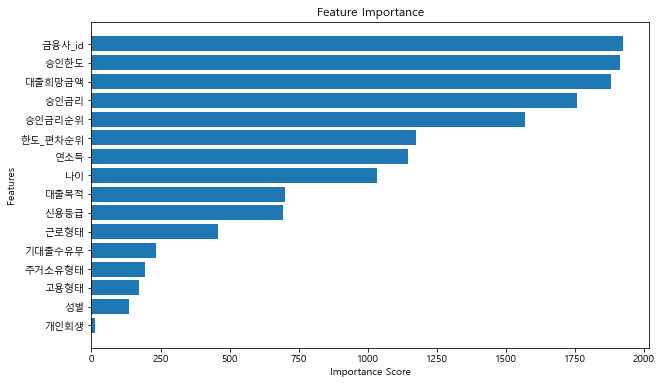

In [64]:
import matplotlib.pyplot as plt
# 변수 중요도 가져오기
importance = model.feature_importances_
features = X_train.columns

# 중요도 기준 내림차순 정렬
indices = np.argsort(importance)[::-1]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importance[indices], align="center")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.gca().invert_yaxis()  # 중요도가 높은 변수가 위쪽에 오도록 반전
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [67]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score


feature_names = X_train.columns

f1_scorer = make_scorer(f1_score, average='binary')  # binary 옵션을 줘야 함

# 순열 중요도 계산
perm_importance = permutation_importance(model, X_test, y_test, scoring=f1_scorer, n_repeats=10, random_state=42)

# 순열 중요도 출력
perm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)
print("🔄 순열 중요도:\n", perm_importance_df)

🔄 순열 중요도:
     Feature  Importance
15   승인금리순위    0.140708
1      승인한도    0.023585
14  한도_편차순위    0.014079
2      승인금리    0.011444
8    대출희망금액    0.009962
0    금융사_id    0.008567
4       연소득    0.005043
9      대출목적    0.002133
13   기대출수유무    0.001135
5      근로형태    0.001021
7    주거소유형태    0.000362
11       나이    0.000176
3        성별    0.000119
6      고용형태    0.000084
12     개인회생    0.000004
10     신용등급   -0.002653


NameError: name 'sns' is not defined

<Figure size 864x432 with 0 Axes>

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_19812\2542962907.py:9: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  plt.savefig(save_path+"lgbm모델_순열중요도.png")
C:\Users\USER\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


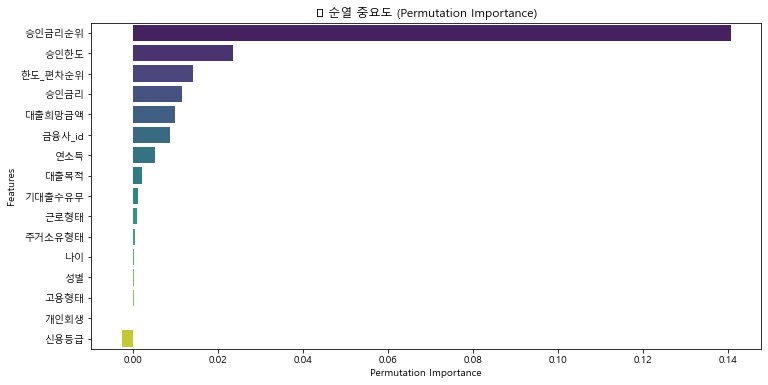

In [72]:
# **✅ 시각화 (Seaborn 사용)**
plt.figure(figsize=(12, 6))
sys.barplot(x='Importance', y='Feature', data=perm_importance_df, palette='viridis')
plt.xlabel("Permutation Importance")
plt.ylabel("Features")
plt.title("🔄 순열 중요도 (Permutation Importance)")

save_path='C:/Users/USER/Desktop/참가 공모전/빅콘(22년 9월)/시각화/'
plt.savefig(save_path+"lgbm모델_순열중요도.png")
plt.show()

In [73]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-Fold Stratified CV

auc_scores = []
f1_score_list=[]
pr_curves = []
thresholds_list = []
recall_list = []

for train_idx, val_idx in kf.split(X, y):  # 클래스 비율 유지하는 Stratified K-Fold
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # LightGBM 하이퍼파라미터 설정
    # 모델 학습
    model = lgb.LGBMClassifier(objective= "binary",
        metric= "f1_score",  
        boosting_type= "gbdt",
        learning_rate= 0.05,
        n_estimators= 500,
        scale_pos_weight = scale_pos_weight,
        verbosity=-1)
    model.fit(X_train, y_train)
    # 검증 데이터 예측 확률 계산
    y_pred = model.predict_proba(X_val)[:, 1]

    # AUC 점수 저장
    auc = roc_auc_score(y_val, y_pred)
    auc_scores.append(auc)

    # 예측 확률을 기준으로 이진 클래스 예측 (임계값: 0.5)
    y_pred_class = (y_pred >= optimal_threshold).astype(int)

    # F1 Score 저장
    f1 = f1_score(y_val, y_pred_class)
    print(f1)
    f1_score_list.append(f1)
    recall = recall_score(y_val, y_pred_class)
    recall_list.append(recall)
    
    # 변수 중요도 저장
    importance = model.feature_importances_
    features = X_train.columns

# 교차검증 평균 AUC 출력
print("Average AUC Score:", np.mean(auc_scores))
print("Average f1-Score:", np.mean(f1_score_list))
print("Average recall:", np.mean(recall_list))


0.4567494445368117
0.4568052958562036
0.4557020308189322
0.4547801861792485
0.4576682570527701
Average AUC Score: 0.9195239262103205
Average f1-Score: 0.4563410428887932
Average recall: 0.539253233694898


In [60]:
# 테스트 데이터 예측
y_test_prob = model.predict(test_loan_df)

# 최적 임계값 적용하여 최종 분류
y_test_pred = (y_test_prob >= optimal_threshold).astype(int)


ValueError: Found input variables with inconsistent numbers of samples: [2054003, 3257239]

In [ ]:
# recall 0.05  , colsample_bytree": 0.7,=> f1 0.405 
# recall 0.05 => f1 0.406
# f1-score 0.05 , n_estimator 300 =>f1 0.41
# f1-score 0.05 , n_estimator 500 => 0.413
# 